In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, cross_val_predict, RandomizedSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, fbeta_score, precision_score, recall_score,
    log_loss, brier_score_loss, accuracy_score
)
from sklearn.calibration import calibration_curve
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import shap, joblib, json, os
from datetime import datetime

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TARGET_COL = 'Attrition'
sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 13})

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

df_raw = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = df_raw.copy()
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df[TARGET_COL] = df[TARGET_COL].map({'Yes': 1, 'No': 0})
df = df.drop_duplicates(keep='first').reset_index(drop=True)

num_cols = df.select_dtypes(include=np.number).columns.drop(TARGET_COL).tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
attrition_rate = df[TARGET_COL].mean() * 100

print(f"Dataset ready: {df.shape[0]:,} rows x {df.shape[1]} cols")

# Part IV. Model implementation



## 4.1 Data splitting

In [55]:
X_base = df.drop(columns=[TARGET_COL])
y_base = df[TARGET_COL]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_base, y_base, test_size=0.15,
    random_state=RANDOM_STATE, stratify=y_base
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176,
    random_state=RANDOM_STATE, stratify=y_temp
)

split_summary = pd.DataFrame({
    'set': ['Train', 'Validation', 'Test'],
    'n_samples': [len(X_train), len(X_val), len(X_test)],
    'pct': [round(len(X_train)/len(X_base)*100, 1),
           round(len(X_val)/len(X_base)*100, 1),
           round(len(X_test)/len(X_base)*100, 1)],
    'attrition_rate': [round(y_train.mean()*100, 2),
                       round(y_val.mean()*100, 2),
                       round(y_test.mean()*100, 2)]
})
split_summary

,set,n_samples,pct,attrition_rate
0,Train,1029,70.0,16.13
1,Validation,220,15.0,15.91
2,Test,221,15.0,16.29


## 4.2 Feature engineering

### 4.2.1 Categorical encoding

In [56]:
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}

def encode_features(X):
    X = X.copy()
    X['BusinessTravel'] = X['BusinessTravel'].map(travel_map)
    X['Gender'] = X['Gender'].map({'Male': 0, 'Female': 1})
    X['OverTime'] = X['OverTime'].map({'No': 0, 'Yes': 1})
    nominal = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
    X = pd.get_dummies(X, columns=nominal, drop_first=True, dtype=int)
    return X

X_train_enc = encode_features(X_train)
X_val_enc = encode_features(X_val)
X_test_enc = encode_features(X_test)

all_cols = sorted(set(X_train_enc.columns)|set(X_val_enc.columns)|set(X_test_enc.columns))
X_train_enc = X_train_enc.reindex(columns=all_cols, fill_value=0)
X_val_enc = X_val_enc.reindex(columns=all_cols, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=all_cols, fill_value=0)

X_train_enc.shape, X_val_enc.shape, X_test_enc.shape

((1029, 43), (220, 43), (221, 43))

### 4.2.2 Binary risk indicator

In [57]:
income_q25_train = X_train_enc['MonthlyIncome'].quantile(0.25)

def add_binary_features(X, income_threshold):
    X = X.copy()
    X['IsYoung'] = (X['Age'] < 30).astype(int)
    X['IsNewHire'] = (X['YearsAtCompany'] < 2).astype(int)
    X['HasStockOption'] = (X['StockOptionLevel'] > 0).astype(int)
    X['IsLowIncome'] = (X['MonthlyIncome'] < income_threshold).astype(int)
    if 'MaritalStatus_Single' in X.columns:
        X['IsSingle'] = X['MaritalStatus_Single'].copy()
    else:
        X['IsSingle'] = 0
    return X

X_train_enc = add_binary_features(X_train_enc, income_q25_train)
X_val_enc = add_binary_features(X_val_enc, income_q25_train)
X_test_enc = add_binary_features(X_test_enc, income_q25_train)

pd.DataFrame({
    'feature': ['IsYoung', 'IsNewHire', 'HasStockOption', 'IsLowIncome', 'IsSingle'],
    'train_count': [X_train_enc[c].sum() for c in ['IsYoung', 'IsNewHire', 'HasStockOption', 'IsLowIncome', 'IsSingle']]})

,feature,train_count
0,IsYoung,226
1,IsNewHire,148
2,HasStockOption,594
3,IsLowIncome,257
4,IsSingle,322


### 4.2.3 Interaction features

In [58]:
def add_interaction_features(X):
    X = X.copy()
    X['OT_LowJobSat'] = ((X['OverTime'] == 1)&(X['JobSatisfaction']<= 2)).astype(int)
    X['OT_LowEnvSat'] = ((X['OverTime'] == 1)&(X['EnvironmentSatisfaction']<= 2)).astype(int)
    X['OT_LowWLB'] = ((X['OverTime'] == 1) & (X['WorkLifeBalance'] <= 2)).astype(int)
    X['ManagerStability'] = X['YearsWithCurrManager']/(X['YearsAtCompany'] + 1)
    X['PromotionGap'] = X['YearsSinceLastPromotion']/(X['YearsAtCompany'] + 1)
    X['IncomePerYear'] = X['MonthlyIncome']/(X['TotalWorkingYears'] + 1)
    return X

X_train_enc = add_interaction_features(X_train_enc)
X_val_enc   = add_interaction_features(X_val_enc)
X_test_enc  = add_interaction_features(X_test_enc)

X_train_enc[['OT_LowJobSat', 'OT_LowEnvSat', 'OT_LowWLB',
             'ManagerStability', 'PromotionGap', 'IncomePerYear']].describe().round(3)

,OT_LowJobSat,OT_LowEnvSat,OT_LowWLB,ManagerStability,PromotionGap,IncomePerYear
count,1029.000,1029.000,1029.000,1029.000,1029.000,1029.000
mean,0.105,0.092,0.082,0.472,0.238,582.164
std,0.307,0.290,0.274,0.278,0.273,284.091
min,0.000,0.000,0.000,0.000,0.000,95.286
25%,0.000,0.000,0.000,0.300,0.000,373.875
50%,0.000,0.000,0.000,0.500,0.143,546.864
75%,0.000,0.000,0.000,0.667,0.455,731.435
max,1.000,1.000,1.000,0.895,0.917,1904.000


### 4.2.4 Log transformations

In [59]:
skewed_features = ['MonthlyIncome', 'NumCompaniesWorked',
                    'YearsSinceLastPromotion', 'DistanceFromHome', 'YearsAtCompany']

for col in skewed_features:
    X_train_enc[f'{col}_log'] = np.log1p(X_train_enc[col])
    X_val_enc[f'{col}_log']   = np.log1p(X_val_enc[col])
    X_test_enc[f'{col}_log']  = np.log1p(X_test_enc[col])

X_train_enc.shape

(1029, 59)

## 4.3 Feature selection

In [60]:
core_numerical = [
    'OverTime', 'MonthlyIncome', 'Age', 'TotalWorkingYears',
    'JobLevel', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsWithCurrManager', 'StockOptionLevel',
    'JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction',
    'BusinessTravel', 'DistanceFromHome',
    'WorkLifeBalance', 'YearsSinceLastPromotion', 'TrainingTimesLastYear'
]

engineered_features = [
    'OT_LowJobSat', 'OT_LowEnvSat', 'OT_LowWLB',
    'HasStockOption', 'IsNewHire', 'IsYoung', 'IsLowIncome',
    'ManagerStability', 'PromotionGap', 'MonthlyIncome_log'
]

jobrole_cols  = [c for c in X_train_enc.columns if c.startswith('JobRole_')]
marital_cols  = [c for c in X_train_enc.columns if c.startswith('MaritalStatus_')]
dept_cols = [c for c in X_train_enc.columns if c.startswith('Department_')]
edfield_cols  = [c for c in X_train_enc.columns if c.startswith('EducationField_')]

final_features = (
    [c for c in core_numerical     if c in X_train_enc.columns] +
    [c for c in engineered_features if c in X_train_enc.columns] +
    jobrole_cols + marital_cols + dept_cols + edfield_cols
)
final_features = list(dict.fromkeys(final_features))

xgb_core = [
    'OverTime', 'MonthlyIncome', 'Age', 'TotalWorkingYears',
    'JobLevel', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsWithCurrManager', 'StockOptionLevel',
    'JobInvolvement', 'JobSatisfaction', 'EnvironmentSatisfaction',
    'BusinessTravel', 'DistanceFromHome',
    'WorkLifeBalance', 'YearsSinceLastPromotion'
]

xgb_features = (
    [c for c in xgb_core if c in X_train_enc.columns] +
    [c for c in engineered_features if c in X_train_enc.columns] +
    jobrole_cols + marital_cols + edfield_cols
)
xgb_features = list(dict.fromkeys(xgb_features))

pd.DataFrame({
    'set': ['LR (final_features)', 'XGB (xgb_features)'],
    'n_features': [len(final_features), len(xgb_features)],
    'note': ['includes Dept + Training', 'no Dept, no Training']
})

,set,n_features,note
0,LR (final_features),44,includes Dept + Training
1,XGB (xgb_features),41,"no Dept, no Training"


In [61]:
X_train_final = X_train_enc[final_features]
X_val_final = X_val_enc[final_features]
X_test_final = X_test_enc[final_features]

X_train_xgb = X_train_enc[xgb_features]
X_val_xgb = X_val_enc[xgb_features]
X_test_xgb = X_test_enc[xgb_features]

n_train = len(X_train_final)
pd.DataFrame({
    'set': ['LR features', 'XGB features'],
    'n_features': [len(final_features), len(xgb_features)],
    'sample_feat_ratio': [round(n_train/len(final_features), 1),
                          round(n_train/len(xgb_features), 1)]})

,set,n_features,sample_feat_ratio
0,LR features,44,23.4
1,XGB features,41,25.1


## 4.4 Imbalance handling

In [62]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_metrics = ['f1', 'roc_auc', 'recall', 'precision', 'average_precision']

## 4.5 Cross-Validation setup

In [63]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
natural_spw = neg_count / pos_count

spw_candidates = [3.0, natural_spw, 7.0, 10.0, 12.0]
spw_cv_results = []

for spw in spw_candidates:
    xgb_probe = XGBClassifier(
        n_estimators=300, max_depth=2, learning_rate=0.03,
        min_child_weight=10, gamma=1, subsample=0.7,
        colsample_bytree=0.6, reg_alpha=1, reg_lambda=10,
        max_delta_step=1, scale_pos_weight=spw,
        random_state=RANDOM_STATE, eval_metric='aucpr', verbosity=0
    )
    scores = cross_validate(
        xgb_probe, X_train_final if 'X_train_final' in dir() else X_train_enc,
        y_train, cv=cv_strat,
        scoring=['recall', 'f1', 'average_precision'],
        n_jobs=-1
    )
    spw_cv_results.append({
        'scale_pos_weight': round(spw, 2),
        'cv_recall': round(scores['test_recall'].mean(), 4),
        'cv_f1': round(scores['test_f1'].mean(), 4),
        'cv_pr_auc': round(scores['test_average_precision'].mean(), 4),
        'recall_std': round(scores['test_recall'].std(), 4)
    })

spw_df = pd.DataFrame(spw_cv_results)

best_spw_row = spw_df.loc[spw_df['cv_f1'].idxmax()]
scale_pos_weight = best_spw_row['scale_pos_weight']

spw_df['selected'] = spw_df['scale_pos_weight'] == scale_pos_weight
spw_df

,scale_pos_weight,cv_recall,cv_f1,cv_pr_auc,recall_std,selected
0,3.0,0.5601,0.5594,0.5979,0.0689,True
1,5.2,0.6922,0.5332,0.6028,0.0859,False
2,7.0,0.7465,0.5037,0.5972,0.0637,False
3,10.0,0.7827,0.4344,0.5893,0.0684,False
4,12.0,0.8189,0.4094,0.5874,0.0643,False


### 4.5 XGBoost Hyperparameter Search: Optimizing F2 Score

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    random_state=RANDOM_STATE,
    eval_metric='aucpr',
    verbosity=0
)

param_distributions = {
    'max_depth':         [1, 2],
    'min_child_weight':  [10, 15, 20, 30],
    'gamma':             [1, 2, 3, 5],
    'reg_alpha':         [1, 2, 5, 10],
    'reg_lambda':        [10, 15, 20, 30],
    'subsample':         [0.55, 0.65, 0.75],
    'colsample_bytree':  [0.45, 0.55, 0.65],
    'scale_pos_weight':  [
        scale_pos_weight,
        round(scale_pos_weight * 1.3, 2),
        round(scale_pos_weight * 1.6, 2),
        round(scale_pos_weight * 2.0, 2)
    ],
    'max_delta_step': [1, 2, 3]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=80,
    scoring=f2_scorer,
    cv=cv_strat,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
    refit=True
)

xgb_search.fit(X_train_xgb, y_train)

pd.Series({
    'best_cv_f2': round(xgb_search.best_score_, 4),
    **xgb_search.best_params_
}).to_frame('xgb_search_results')

,xgb_search_results
best_cv_f2,0.6043
subsample,0.5500
scale_pos_weight,6.0000
reg_lambda,10.0000
reg_alpha,10.0000
min_child_weight,30.0000
max_depth,1.0000
max_delta_step,2.0000
gamma,2.0000
colsample_bytree,0.4500


## 4.6 Baseline Model: Logistic Regression

In [65]:
pipeline_lr = ImbPipeline([
    ('scaler', RobustScaler()),
    ('clf', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        C=1.0,
        random_state=RANDOM_STATE
    ))
])

lr_cv = cross_validate(
    pipeline_lr, X_train_final, y_train, cv=cv_strat,
    scoring=scoring_metrics, return_train_score=True, n_jobs=-1
)

lr_cv_summary = pd.DataFrame({
    'metric': scoring_metrics,
    'train': [round(lr_cv[f'train_{m}'].mean(), 4) for m in scoring_metrics],
    'val_mean': [round(lr_cv[f'test_{m}'].mean(), 4)  for m in scoring_metrics],
    'val_std': [round(lr_cv[f'test_{m}'].std(), 4)   for m in scoring_metrics]
})
lr_cv_summary['gap'] = (lr_cv_summary['train'] - lr_cv_summary['val_mean']).round(4)
lr_cv_summary

,metric,train,val_mean,val_std,gap
0,f1,0.5612,0.4947,0.0147,0.0665
1,roc_auc,0.8795,0.8152,0.0234,0.0643
2,recall,0.7922,0.6927,0.0234,0.0995
3,precision,0.4347,0.3850,0.0149,0.0497
4,average_precision,0.7036,0.6206,0.0792,0.0830


In [66]:
pipeline_lr.fit(X_train_final, y_train)
lr_val_prob = pipeline_lr.predict_proba(X_val_final)[:, 1]
lr_val_pred = pipeline_lr.predict(X_val_final)

lr_val_metrics = {
    'accuracy':  round((lr_val_pred == y_val).mean(), 4),
    'precision': round(precision_score(y_val, lr_val_pred), 4),
    'recall':    round(recall_score(y_val, lr_val_pred), 4),
    'f1':        round(f1_score(y_val, lr_val_pred), 4),
    'roc_auc':   round(roc_auc_score(y_val, lr_val_prob), 4),
    'pr_auc':    round(average_precision_score(y_val, lr_val_prob), 4)
}
pd.Series(lr_val_metrics, name='LR_Validation').to_frame()

,LR_Validation
accuracy,0.7545
precision,0.3699
recall,0.7714
f1,0.5000
roc_auc,0.8170
pr_auc,0.5782


## 4.7 Main Model: XGBoost

In [67]:
xgb_model = xgb_search.best_estimator_

xgb_cv = cross_validate(
    xgb_model, X_train_xgb, y_train, cv=cv_strat,
    scoring=scoring_metrics, return_train_score=True, n_jobs=-1
)

xgb_cv_summary = pd.DataFrame({
    'metric': scoring_metrics,
    'train': [round(xgb_cv[f'train_{m}'].mean(), 4) for m in scoring_metrics],
    'val_mean': [round(xgb_cv[f'test_{m}'].mean(), 4)  for m in scoring_metrics],
    'val_std': [round(xgb_cv[f'test_{m}'].std(), 4)   for m in scoring_metrics]
})
xgb_cv_summary['gap'] = (xgb_cv_summary['train'] - xgb_cv_summary['val_mean']).round(4)
xgb_cv_summary

,metric,train,val_mean,val_std,gap
0,f1,0.4996,0.4671,0.0273,0.0325
1,roc_auc,0.8386,0.7886,0.0349,0.0500
2,recall,0.8057,0.7529,0.0405,0.0528
3,precision,0.3622,0.3394,0.0270,0.0228
4,average_precision,0.6214,0.5588,0.0935,0.0626


In [68]:
xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=False
)

xgb_val_prob = xgb_model.predict_proba(X_val_xgb)[:, 1]
xgb_val_pred = xgb_model.predict(X_val_xgb)

xgb_val_metrics = {
    'accuracy':  round((xgb_val_pred == y_val).mean(), 4),
    'precision': round(precision_score(y_val, xgb_val_pred), 4),
    'recall':    round(recall_score(y_val, xgb_val_pred), 4),
    'f1':        round(f1_score(y_val, xgb_val_pred), 4),
    'roc_auc':   round(roc_auc_score(y_val, xgb_val_prob), 4),
    'pr_auc':    round(average_precision_score(y_val, xgb_val_prob), 4)
}
pd.Series(xgb_val_metrics, name='XGB_Validation').to_frame()

,XGB_Validation
accuracy,0.6773
precision,0.2805
recall,0.6571
f1,0.3932
roc_auc,0.7700
pr_auc,0.5654


#




In [69]:
gap_analysis = pd.DataFrame({
    'model':     ['Logistic Regression', 'XGBoost'],
    'cv_train_f1': [
        round(lr_cv['train_f1'].mean(), 4),
        round(xgb_cv['train_f1'].mean(), 4)
    ],
    'cv_val_f1': [
        round(lr_cv['test_f1'].mean(), 4),
        round(xgb_cv['test_f1'].mean(), 4)
    ],
})
gap_analysis['gap']     = (gap_analysis['cv_train_f1'] - gap_analysis['cv_val_f1']).round(4)
gap_analysis['verdict'] = gap_analysis['gap'].apply(
    lambda x: 'Healthy (< 0.10)' if x < 0.10 else 'Possible overfit (>= 0.10)'
)
gap_analysis

,model,cv_train_f1,cv_val_f1,gap,verdict
0,Logistic Regression,0.5612,0.4947,0.0665,Healthy (< 0.10)
1,XGBoost,0.4996,0.4671,0.0325,Healthy (< 0.10)


## 4.9 Validation metrics comparison


In [70]:
val_comparison = pd.DataFrame([
    {**{'model': 'Logistic Regression'}, **lr_val_metrics},
    {**{'model': 'XGBoost'}, **xgb_val_metrics}
]).set_index('model')
val_comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.7545,0.3699,0.7714,0.5000,0.817,0.5782
XGBoost,0.6773,0.2805,0.6571,0.3932,0.770,0.5654


In [71]:
from sklearn.metrics import accuracy_score, fbeta_score

def threshold_search(y_true, prob, model_name):
    thresholds = np.arange(0.10, 0.71, 0.02)
    rows = []

    for t in thresholds:
        pred = (prob >= t).astype(int)
        rows.append({
            'model': model_name,
            'threshold': round(t, 2),
            'accuracy': round(accuracy_score(y_true, pred), 4),
            'precision': round(precision_score(y_true, pred, zero_division=0), 4),
            'recall': round(recall_score(y_true, pred, zero_division=0), 4),
            'f1': round(f1_score(y_true, pred, zero_division=0), 4),
            'f2': round(fbeta_score(y_true, pred, beta=2, zero_division=0), 4),
            'roc_auc': round(roc_auc_score(y_true, prob), 4)
        })

    return pd.DataFrame(rows)

lr_threshold_df = threshold_search(y_val, lr_val_prob, "Logistic Regression")
xgb_threshold_df = threshold_search(y_val, xgb_val_prob, "XGBoost")

threshold_all = pd.concat([lr_threshold_df, xgb_threshold_df], ignore_index=True)
threshold_all

,model,threshold,accuracy,precision,recall,f1,f2,roc_auc
0,Logistic Regression,0.10,0.3045,0.1793,0.9429,0.3014,0.5093,0.817
1,Logistic Regression,0.12,0.3500,0.1897,0.9429,0.3158,0.5255,0.817
2,Logistic Regression,0.14,0.3909,0.2000,0.9429,0.3300,0.5410,0.817
3,Logistic Regression,0.16,0.4136,0.2062,0.9429,0.3385,0.5500,0.817
4,Logistic Regression,0.18,0.4409,0.2105,0.9143,0.3422,0.5479,0.817
...,...,...,...,...,...,...,...,...
57,XGBoost,0.62,0.8227,0.4565,0.6000,0.5185,0.5645,0.770
58,XGBoost,0.64,0.8318,0.4762,0.5714,0.5195,0.5495,0.770
59,XGBoost,0.66,0.8545,0.5429,0.5429,0.5429,0.5429,0.770
60,XGBoost,0.68,0.8682,0.6000,0.5143,0.5538,0.5294,0.770


In [72]:
def choose_threshold(threshold_df, min_precision=0.35, min_recall=0.75):
    candidates = threshold_df[
        (threshold_df['precision'] >= min_precision) &
        (threshold_df['recall'] >= min_recall)
    ]

    if len(candidates) > 0:
        return candidates.sort_values('f2', ascending=False).iloc[0]

    return threshold_df.sort_values('f2', ascending=False).iloc[0]

lr_best_threshold = choose_threshold(lr_threshold_df, min_precision=0.35, min_recall=0.75)
xgb_best_threshold = choose_threshold(xgb_threshold_df, min_precision=0.35, min_recall=0.75)

threshold_summary_both = pd.DataFrame([
    lr_best_threshold,
    xgb_best_threshold
])

threshold_summary_both

,model,threshold,accuracy,precision,recall,f1,f2,roc_auc
19,Logistic Regression,0.48,0.7409,0.3590,0.8000,0.4956,0.6422,0.817
19,XGBoost,0.48,0.6682,0.2935,0.7714,0.4252,0.5819,0.770


In [73]:
val_comparison.to_csv("results/validation_comparison.csv")

## 4.10 ROC and Precision-Recall Curves

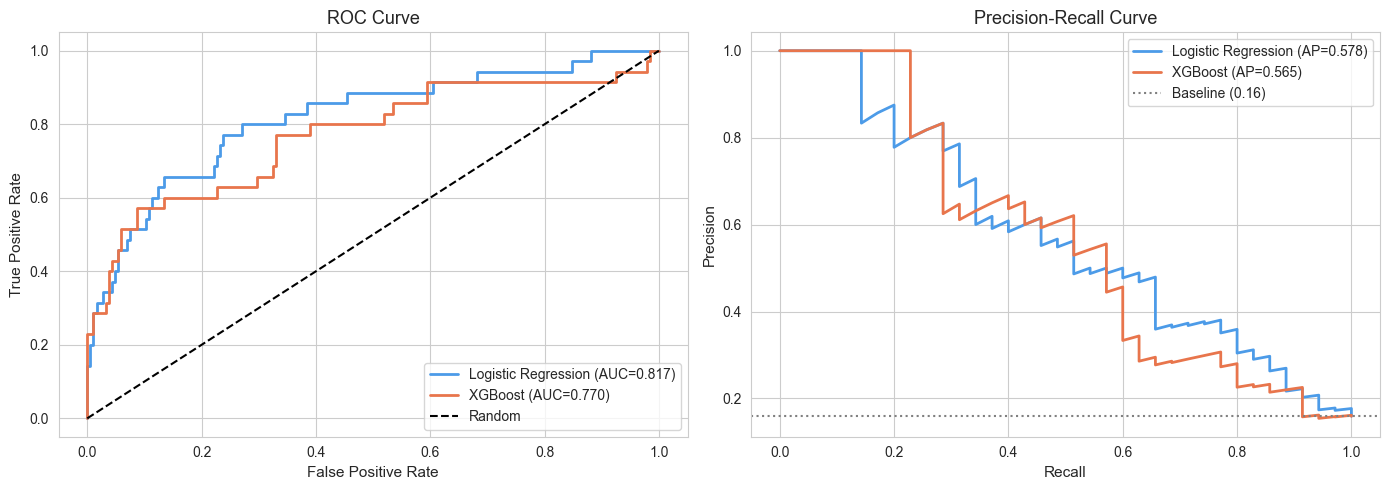

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_probs = [
    ('Logistic Regression', lr_val_prob,  '#4C9BE8'),
    ('XGBoost',             xgb_val_prob, '#E8754C')
]

for name, prob, color in model_probs:
    fpr, tpr, _ = roc_curve(y_val, prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC={roc_auc_score(y_val, prob):.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

for name, prob, color in model_probs:
    prec, rec, _ = precision_recall_curve(y_val, prob)
    ap = average_precision_score(y_val, prob)
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.3f})")
axes[1].axhline(y_val.mean(), color='gray', ls=':',
                label=f'Baseline ({y_val.mean():.2f})')
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/roc_pr_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## 4.11 Model selection

In [75]:
selection_score = pd.DataFrame({
    'model': ['Logistic Regression', 'XGBoost'],
    'val_recall': [lr_val_metrics['recall'],  xgb_val_metrics['recall']],
    'val_f1': [lr_val_metrics['f1'],      xgb_val_metrics['f1']],
    'val_roc_auc': [lr_val_metrics['roc_auc'], xgb_val_metrics['roc_auc']],
    'cv_gap': gap_analysis['gap'].values
})
selection_score = selection_score.sort_values(['val_recall', 'val_roc_auc'], ascending=[False, False])
selection_score

,model,val_recall,val_f1,val_roc_auc,cv_gap
0,Logistic Regression,0.7714,0.5000,0.817,0.0665
1,XGBoost,0.6571,0.3932,0.770,0.0325


In [76]:
best_model_name = selection_score.iloc[0]['model']
model_objects = {
    'Logistic Regression': pipeline_lr,
    'XGBoost': xgb_model
}

best_model = model_objects[best_model_name]

pd.DataFrame({
    'selected_model': [best_model_name],
    'reason': [f"Highest val_recall = {selection_score.iloc[0]['val_recall']:.4f}"]})

,selected_model,reason
0,Logistic Regression,Highest val_recall = 0.7714


## 4.12 CV based threshold tuning (Multiple objectives)


In [77]:
cv_probs = cross_val_predict(
    best_model, X_train_final, y_train, cv=cv_strat,
    method='predict_proba', n_jobs=-1
)[:, 1]

thresholds = np.arange(0.10, 0.71, 0.02)
threshold_results = []
for t in thresholds:
    preds = (cv_probs >= t).astype(int)
    threshold_results.append({
        'threshold': round(t, 2),
        'precision': round(precision_score(y_train, preds, zero_division=0), 4),
        'recall': round(recall_score(y_train, preds, zero_division=0), 4),
        'f1': round(f1_score(y_train, preds, zero_division=0), 4),
        'f2': round(fbeta_score(y_train, preds, beta=2, zero_division=0), 4),
        'f0_5': round(fbeta_score(y_train, preds, beta=0.5, zero_division=0), 4)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1,f2,f0_5
0,0.10,0.2013,0.9337,0.3312,0.5404,0.2388
1,0.12,0.2049,0.9036,0.3341,0.5372,0.2424
2,0.14,0.2128,0.9036,0.3444,0.5478,0.2512
3,0.16,0.2183,0.8916,0.3507,0.5514,0.2571
4,0.18,0.2266,0.8916,0.3614,0.5619,0.2664
5,0.20,0.2344,0.8855,0.3707,0.5693,0.2749
6,0.22,0.2429,0.8795,0.3807,0.5771,0.2840
7,0.24,0.2449,0.8614,0.3813,0.5729,0.2858
8,0.26,0.2559,0.8494,0.3933,0.5802,0.2975
9,0.28,0.2598,0.8373,0.3966,0.5796,0.3014


In [78]:
threshold_best_f1 = threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold']
threshold_best_f2 = threshold_df.loc[threshold_df['f2'].idxmax(), 'threshold']

precision_floor = 0.30
recall_floor = 0.65
mask = (threshold_df['precision'] >= precision_floor) & (threshold_df['recall'] >= recall_floor)
if mask.any():
    threshold_high_recall = threshold_df[mask].sort_values('recall', ascending=False).iloc[0]['threshold']
else:
    threshold_high_recall = threshold_df.sort_values('recall', ascending=False).iloc[0]['threshold']

threshold_summary = pd.DataFrame({
    'strategy':  ['Max F1 (balanced)',
                  'Max F2 (recall-weighted, RECOMMENDED)',
                  f'Max Recall (precision >= {precision_floor})'],
    'threshold': [threshold_best_f1, threshold_best_f2, threshold_high_recall],
    'precision': [threshold_df.loc[threshold_df['threshold']==threshold_best_f1,    'precision'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_best_f2,    'precision'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_high_recall,'precision'].iloc[0]],
    'recall':    [threshold_df.loc[threshold_df['threshold']==threshold_best_f1,    'recall'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_best_f2,    'recall'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_high_recall,'recall'].iloc[0]],
    'f1':        [threshold_df.loc[threshold_df['threshold']==threshold_best_f1,    'f1'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_best_f2,    'f1'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_high_recall,'f1'].iloc[0]],
    'f2':        [threshold_df.loc[threshold_df['threshold']==threshold_best_f1,    'f2'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_best_f2,    'f2'].iloc[0],
                  threshold_df.loc[threshold_df['threshold']==threshold_high_recall,'f2'].iloc[0]]
})
threshold_summary

,strategy,threshold,precision,recall,f1,f2
0,Max F1 (balanced),0.70,0.5814,0.6024,0.5917,0.5981
1,"Max F2 (recall-weighted, RECOMMENDED)",0.42,0.3404,0.7711,0.4723,0.6154
2,Max Recall (precision >= 0.3),0.38,0.3099,0.7952,0.4459,0.6055


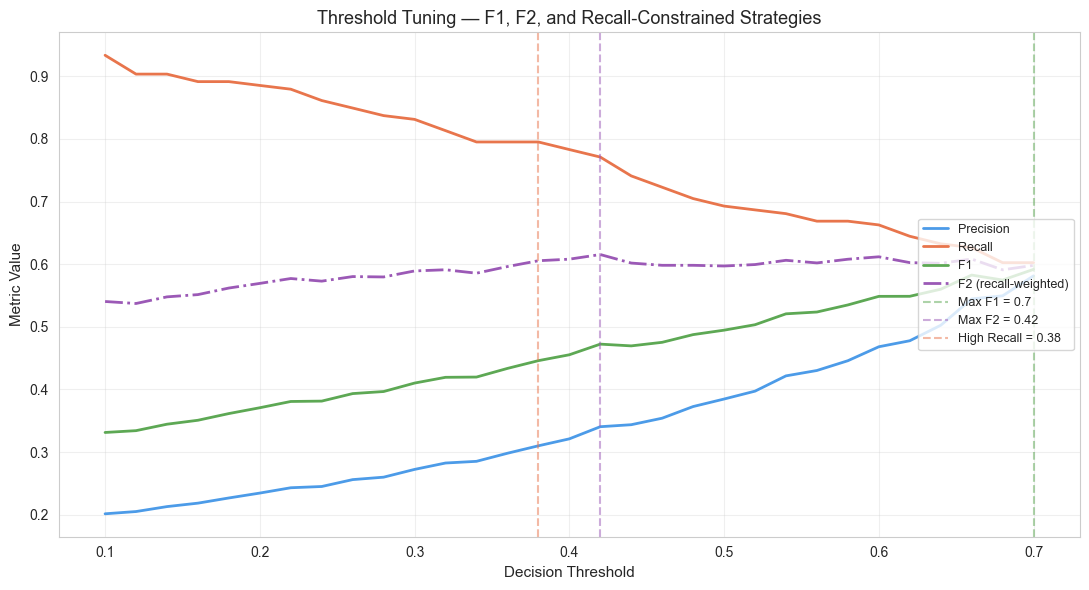

In [79]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', color='#4C9BE8', lw=2)
ax.plot(threshold_df['threshold'], threshold_df['recall'],    label='Recall',    color='#E8754C', lw=2)
ax.plot(threshold_df['threshold'], threshold_df['f1'],        label='F1',        color='#5DA854', lw=2)
ax.plot(threshold_df['threshold'], threshold_df['f2'],        label='F2 (recall-weighted)',
        color='#9B59B6', lw=2, ls='-.')

ax.axvline(threshold_best_f1,     color='#5DA854', ls='--', alpha=0.5, label=f'Max F1 = {threshold_best_f1}')
ax.axvline(threshold_best_f2,     color='#9B59B6', ls='--', alpha=0.5, label=f'Max F2 = {threshold_best_f2}')
ax.axvline(threshold_high_recall, color='#E8754C', ls='--', alpha=0.5, label=f'High Recall = {threshold_high_recall}')

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Metric Value")
ax.set_title("Threshold Tuning — F1, F2, and Recall-Constrained Strategies")
ax.legend(loc='center right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/threshold_tuning.png", dpi=150, bbox_inches='tight')
plt.show()

## 4.13 Top k risk ranking

In [80]:
def topk_metrics(y_true, y_prob, k_pct):
    n = len(y_true)
    k = int(np.ceil(n * k_pct / 100))
    top_k_idx = np.argsort(y_prob)[::-1][:k]
    top_k_labels = np.array(y_true)[top_k_idx]

    n_caught     = int(top_k_labels.sum())
    n_total_pos  = int(np.sum(y_true))
    baseline_rate = n_total_pos / n

    precision_at_k = n_caught / k if k > 0 else 0
    recall_at_k    = n_caught / n_total_pos if n_total_pos > 0 else 0
    lift_at_k      = precision_at_k / baseline_rate if baseline_rate > 0 else 0

    return {
        'k_pct':               k_pct,
        'k_employees':         k,
        'true_leavers_caught': n_caught,
        'total_leavers':       n_total_pos,
        'precision_at_k':      round(precision_at_k, 4),
        'recall_at_k':         round(recall_at_k, 4),
        'lift_at_k':           round(lift_at_k, 2)
    }

cv_topk_results = pd.DataFrame([
    topk_metrics(y_train.values, cv_probs, k) for k in [5, 10, 15, 20, 25, 30, 40, 50]
])
cv_topk_results

,k_pct,k_employees,true_leavers_caught,total_leavers,precision_at_k,recall_at_k,lift_at_k
0,5,52,42,166,0.8077,0.2530,5.01
1,10,103,77,166,0.7476,0.4639,4.63
2,15,155,96,166,0.6194,0.5783,3.84
3,20,206,105,166,0.5097,0.6325,3.16
4,25,258,111,166,0.4302,0.6687,2.67
5,30,309,116,166,0.3754,0.6988,2.33
6,40,412,131,166,0.3180,0.7892,1.97
7,50,515,138,166,0.2680,0.8313,1.66


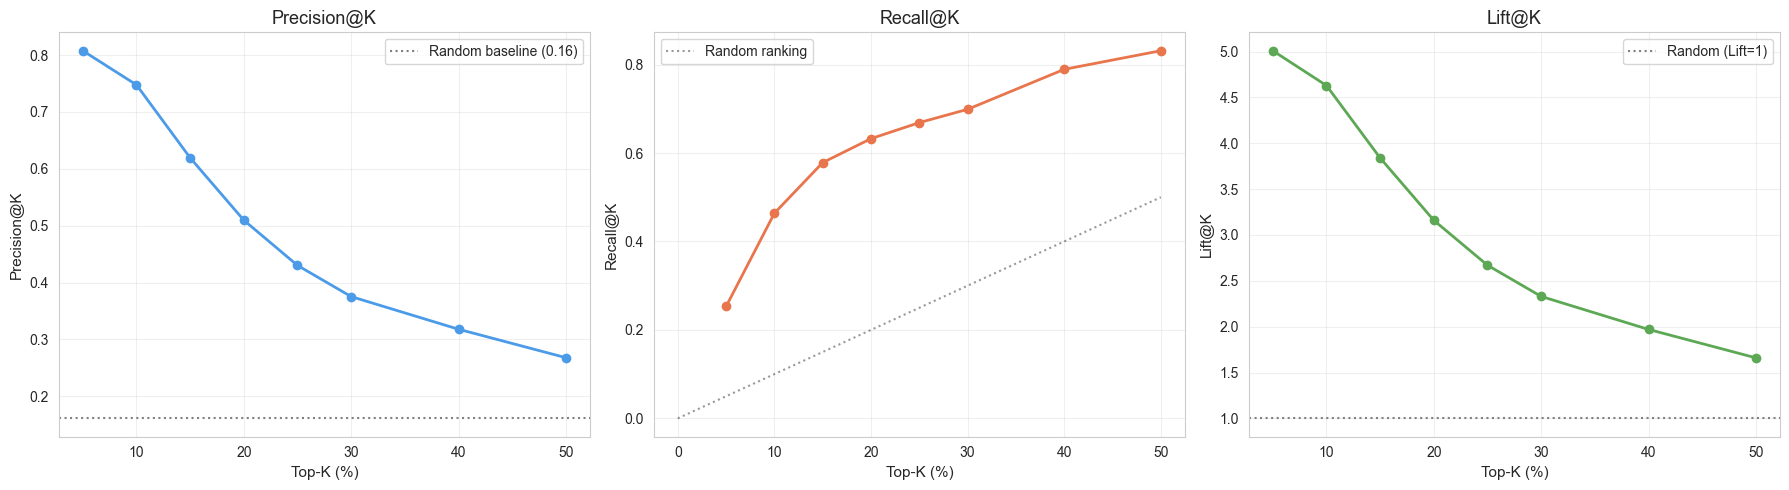

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(cv_topk_results['k_pct'], cv_topk_results['precision_at_k'],
             marker='o', color='#4C9BE8', lw=2)
axes[0].axhline(y_train.mean(), color='gray', ls=':',
                label=f'Random baseline ({y_train.mean():.2f})')
axes[0].set_xlabel("Top-K (%)")
axes[0].set_ylabel("Precision@K")
axes[0].set_title("Precision@K")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cv_topk_results['k_pct'], cv_topk_results['recall_at_k'],
             marker='o', color='#E8754C', lw=2)
axes[1].plot([0, 50], [0, 0.5], 'k:', alpha=0.4, label='Random ranking')
axes[1].set_xlabel("Top-K (%)")
axes[1].set_ylabel("Recall@K")
axes[1].set_title("Recall@K")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(cv_topk_results['k_pct'], cv_topk_results['lift_at_k'],
             marker='o', color='#5DA854', lw=2)
axes[2].axhline(1, color='gray', ls=':', label='Random (Lift=1)')
axes[2].set_xlabel("Top-K (%)")
axes[2].set_ylabel("Lift@K")
axes[2].set_title("Lift@K")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/topk_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## 4.14 SHAP Interpretation

C:\Users\Nguyen\AppData\Local\Temp\ipykernel_28004\3865362533.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, plot_type='bar',


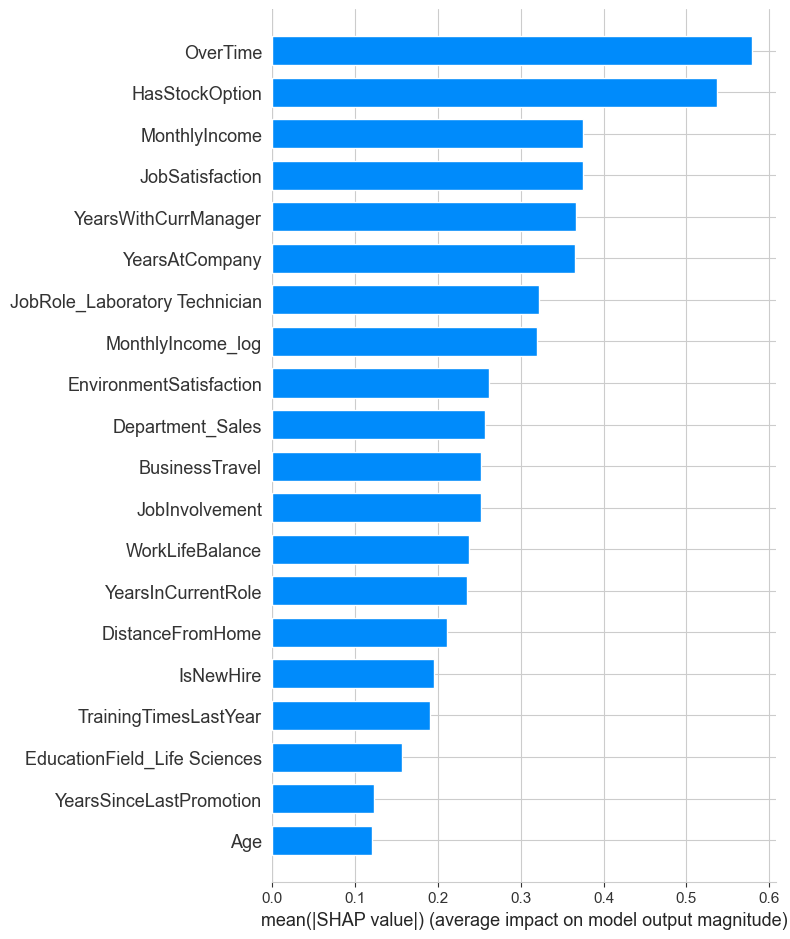

In [82]:
if best_model_name == 'XGBoost':
    shap_input = X_val_xgb
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(shap_input)
else:
    shap_input = X_val_final
    background = shap.sample(X_train_final, 100, random_state=RANDOM_STATE)
    scaler_obj = pipeline_lr.named_steps['scaler']
    clf_obj = pipeline_lr.named_steps['clf']
    explainer = shap.LinearExplainer(clf_obj, scaler_obj.transform(background))
    shap_values = explainer.shap_values(scaler_obj.transform(shap_input))

shap.summary_plot(shap_values, shap_input, plot_type='bar',
                  show=False, max_display=20)
plt.tight_layout()
plt.savefig("results/shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Nguyen\AppData\Local\Temp\ipykernel_28004\1756739879.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_input, show=False, max_display=20)


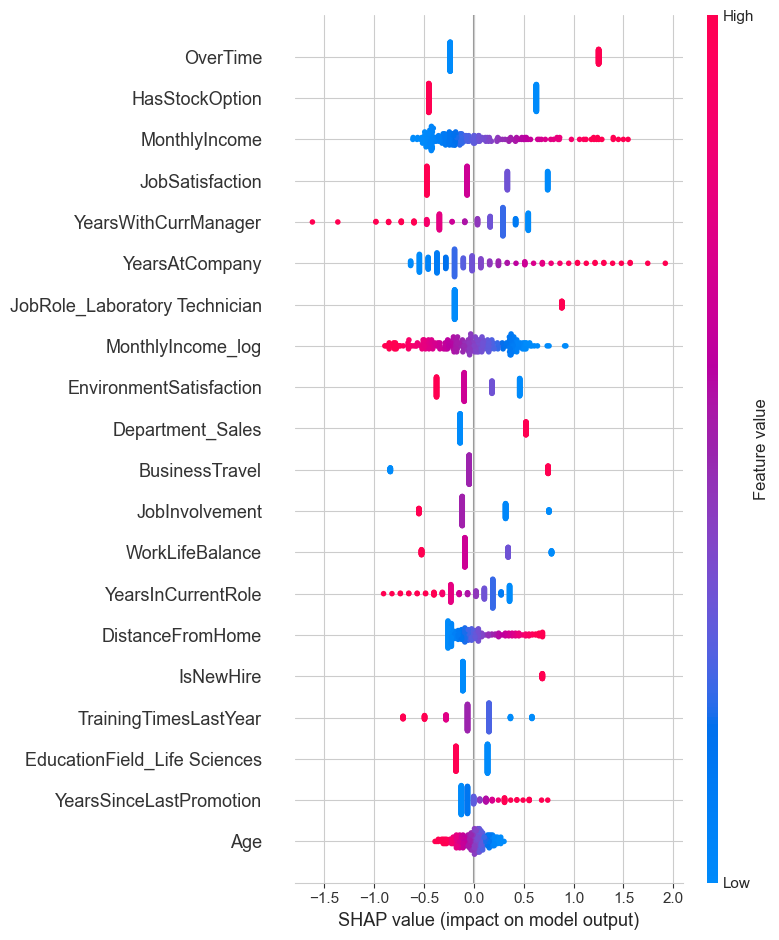

In [83]:
shap.summary_plot(shap_values, shap_input, show=False, max_display=20)
plt.tight_layout()
plt.savefig("results/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

## 4.15 Final Test Evaluation

In [84]:
def eval_at_threshold(y, prob, t, label):
    pred = (prob >= t).astype(int)
    return {
        'config':    label,
        'threshold': t,
        'precision': round(precision_score(y, pred, zero_division=0), 4),
        'recall':    round(recall_score(y, pred, zero_division=0), 4),
        'f1':        round(f1_score(y, pred, zero_division=0), 4),
        'f2':        round(fbeta_score(y, pred, beta=2, zero_division=0), 4),
        'roc_auc':   round(roc_auc_score(y, prob), 4)
    }

lr_test_prob  = pipeline_lr.predict_proba(X_test_final)[:, 1]
xgb_test_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]

if best_model_name == 'XGBoost':
    best_test_prob = xgb_test_prob
else:
    best_test_prob = lr_test_prob

best_test_pred_default = (best_test_prob >= 0.5).astype(int)
best_test_pred_f1      = (best_test_prob >= threshold_best_f1).astype(int)
best_test_pred_f2      = (best_test_prob >= threshold_best_f2).astype(int)
best_test_pred_recall  = (best_test_prob >= threshold_high_recall).astype(int)

lr_tuned_threshold  = threshold_best_f2 if best_model_name == 'Logistic Regression' else threshold_best_f1
xgb_tuned_threshold = xgb_best_threshold['threshold'] if 'xgb_best_threshold' in dir() else threshold_best_f2

test_results = pd.DataFrame([
    eval_at_threshold(y_test, lr_test_prob,  0.50,               'LR default 0.50'),
    eval_at_threshold(y_test, lr_test_prob,  lr_tuned_threshold,  f'LR tuned {lr_tuned_threshold:.2f}'),
    eval_at_threshold(y_test, xgb_test_prob, 0.50,               'XGB default 0.50'),
    eval_at_threshold(y_test, xgb_test_prob, xgb_tuned_threshold, f'XGB tuned {xgb_tuned_threshold:.2f}')
])
test_results

,config,threshold,precision,recall,f1,f2,roc_auc
0,LR default 0.50,0.50,0.4426,0.7500,0.5567,0.6585,0.8647
1,LR tuned 0.42,0.42,0.3580,0.8056,0.4957,0.6444,0.8647
2,XGB default 0.50,0.50,0.3647,0.8611,0.5124,0.6769,0.8225
3,XGB tuned 0.48,0.48,0.3523,0.8611,0.5000,0.6681,0.8225


In [85]:
test_results.to_csv("results/final_test_results.csv", index=False)

### 4.15.1 Top-K Risk Ranking: Test Set Validation

In [86]:
test_topk_results = pd.DataFrame([
    topk_metrics(y_test.values, best_test_prob, k) for k in [5, 10, 15, 20, 25, 30, 40, 50]
])
test_topk_results

,k_pct,k_employees,true_leavers_caught,total_leavers,precision_at_k,recall_at_k,lift_at_k
0,5,12,11,36,0.9167,0.3056,5.63
1,10,23,14,36,0.6087,0.3889,3.74
2,15,34,20,36,0.5882,0.5556,3.61
3,20,45,21,36,0.4667,0.5833,2.86
4,25,56,24,36,0.4286,0.6667,2.63
5,30,67,27,36,0.4030,0.7500,2.47
6,40,89,30,36,0.3371,0.8333,2.07
7,50,111,35,36,0.3153,0.9722,1.94


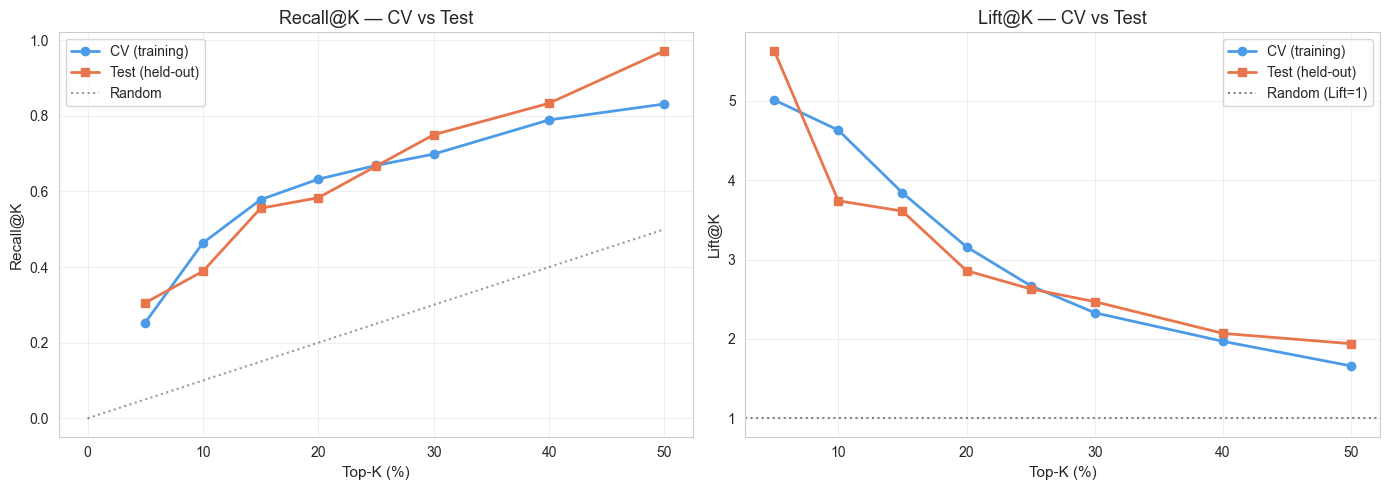

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cv_topk_results['k_pct'],  cv_topk_results['recall_at_k'],
             marker='o', color='#4C9BE8', lw=2, label='CV (training)')
axes[0].plot(test_topk_results['k_pct'], test_topk_results['recall_at_k'],
             marker='s', color='#E8754C', lw=2, label='Test (held-out)')
axes[0].plot([0, 50], [0, 0.5], 'k:', alpha=0.4, label='Random')
axes[0].set_xlabel("Top-K (%)")
axes[0].set_ylabel("Recall@K")
axes[0].set_title("Recall@K — CV vs Test")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cv_topk_results['k_pct'],  cv_topk_results['lift_at_k'],
             marker='o', color='#4C9BE8', lw=2, label='CV (training)')
axes[1].plot(test_topk_results['k_pct'], test_topk_results['lift_at_k'],
             marker='s', color='#E8754C', lw=2, label='Test (held-out)')
axes[1].axhline(1, color='gray', ls=':', label='Random (Lift=1)')
axes[1].set_xlabel("Top-K (%)")
axes[1].set_ylabel("Lift@K")
axes[1].set_title("Lift@K — CV vs Test")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/topk_test_validation.png", dpi=150, bbox_inches='tight')
plt.show()

In [88]:
test_topk_results.to_csv("results/topk_test_results.csv", index=False)

### 4.15.2 Test Set Confusion Matrices: Three Operating Points

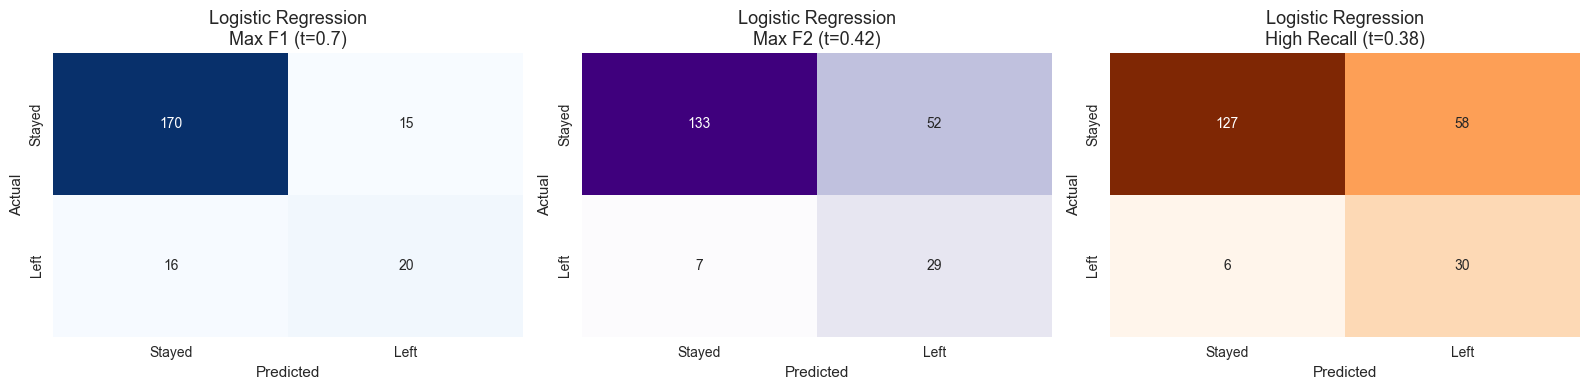

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_configs = [
    (best_test_pred_f1,     "Max F1 (t=" + str(threshold_best_f1) + ")",         'Blues'),
    (best_test_pred_f2,     "Max F2 (t=" + str(threshold_best_f2) + ")",         'Purples'),
    (best_test_pred_recall, "High Recall (t=" + str(threshold_high_recall) + ")", 'Oranges')
]

for ax, (pred, title, cmap) in zip(axes, cm_configs):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d',
                cmap=cmap, ax=ax, cbar=False,
                xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
    ax.set_title(best_model_name + "\n" + title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("results/test_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

### 4.15.3 Business Impact Translation

In [90]:
def business_impact(y_true, prob, threshold, label):
    y_pred = (prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'config': label,
        'threshold': round(threshold, 2),
        'flagged_for_action': int(tp + fp),
        'true_at_risk_caught': int(tp),
        'missed_leavers': int(fn),
        'false_alarms': int(fp),
        'catch_rate_%': round(tp / (tp + fn) * 100, 1) if (tp + fn) > 0 else 0,
        'alarm_accuracy_%': round(tp / (tp + fp) * 100, 1) if (tp + fp) > 0 else 0
    }

def business_impact_from_pred(y_true, y_pred, label):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'config': label,
        'threshold': 'top-k',
        'flagged_for_action': int(tp + fp),
        'true_at_risk_caught': int(tp),
        'missed_leavers': int(fn),
        'false_alarms': int(fp),
        'catch_rate_%': round(tp / (tp + fn) * 100, 1) if (tp + fn) > 0 else 0,
        'alarm_accuracy_%': round(tp / (tp + fp) * 100, 1) if (tp + fp) > 0 else 0
    }

def topk_business_impact(y_true, y_prob, k_pct, label):
    n = len(y_true)
    k = int(np.ceil(n * k_pct / 100))
    top_k_idx = np.argsort(y_prob)[::-1][:k]

    y_pred = np.zeros(n, dtype=int)
    y_pred[top_k_idx] = 1

    return business_impact_from_pred(y_true, y_pred, label)

business_summary = pd.DataFrame([
    business_impact(y_test, lr_test_prob, 0.50, 'LR default 0.50'),
    business_impact(y_test, lr_test_prob, lr_tuned_threshold, f'LR tuned {lr_tuned_threshold:.2f}'),

    business_impact(y_test, xgb_test_prob, 0.50, 'XGB default 0.50'),
    business_impact(y_test, xgb_test_prob, xgb_tuned_threshold, f'XGB tuned {xgb_tuned_threshold:.2f}'),

    topk_business_impact(y_test.values, lr_test_prob, 20, 'LR top 20% riskiest'),
    topk_business_impact(y_test.values, xgb_test_prob, 20, 'XGB top 20% riskiest')
])

business_summary


,config,threshold,flagged_for_action,true_at_risk_caught,missed_leavers,false_alarms,catch_rate_%,alarm_accuracy_%
0,LR default 0.50,0.5,61,27,9,34,75.0,44.3
1,LR tuned 0.42,0.42,81,29,7,52,80.6,35.8
2,XGB default 0.50,0.5,85,31,5,54,86.1,36.5
3,XGB tuned 0.48,0.48,88,31,5,57,86.1,35.2
4,LR top 20% riskiest,top-k,45,21,15,24,58.3,46.7
5,XGB top 20% riskiest,top-k,45,22,14,23,61.1,48.9


In [91]:
business_summary.to_csv("results/business_impact.csv", index=False)

## 4.16 Bootstrap Confidence Intervals for Test Metrics

In [92]:
def bootstrap_metric_ci(y_true, y_pred, y_prob, metric_fn, n_bootstrap=1000, ci=0.95):
    rng = np.random.RandomState(RANDOM_STATE)
    n = len(y_true)
    bootstrap_scores = []
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    y_prob_arr = np.asarray(y_prob) if y_prob is not None else None

    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        if len(np.unique(y_true_arr[idx])) < 2:
            continue
        try:
            if y_prob_arr is not None and metric_fn.__name__ in ['roc_auc_score', 'average_precision_score']:
                score = metric_fn(y_true_arr[idx], y_prob_arr[idx])
            else:
                score = metric_fn(y_true_arr[idx], y_pred_arr[idx])
            bootstrap_scores.append(score)
        except Exception:
            continue

    bootstrap_scores = np.array(bootstrap_scores)
    lower = np.percentile(bootstrap_scores, (1 - ci) / 2 * 100)
    upper = np.percentile(bootstrap_scores, (1 + ci) / 2 * 100)
    return {
        'mean':       round(bootstrap_scores.mean(), 4),
        'std':        round(bootstrap_scores.std(), 4),
        'ci_lower':   round(lower, 4),
        'ci_upper':   round(upper, 4),
        'ci_width':   round(upper - lower, 4)
    }

bootstrap_results = []
for metric_name, metric_fn, needs_prob in [
    ('precision', precision_score,             False),
    ('recall',    recall_score,                False),
    ('f1',        f1_score,                    False),
    ('roc_auc',   roc_auc_score,               True),
    ('pr_auc',    average_precision_score,     True)
]:
    res = bootstrap_metric_ci(
        y_test, best_test_pred_f2,
        best_test_prob if needs_prob else None,
        metric_fn, n_bootstrap=1000
    )
    bootstrap_results.append({
        'metric':   metric_name,
        'estimate': res['mean'],
        '95%_CI':   f"[{res['ci_lower']}, {res['ci_upper']}]",
        'CI_width': res['ci_width'],
        'std':      res['std']
    })

bootstrap_df = pd.DataFrame(bootstrap_results)
bootstrap_df

,metric,estimate,95%_CI,CI_width,std
0,precision,0.3593,"[0.2571, 0.4684]",0.2112,0.0531
1,recall,0.8102,"[0.6774, 0.9286]",0.2512,0.0631
2,f1,0.4956,"[0.3838, 0.5986]",0.2148,0.0557
3,roc_auc,0.8666,"[0.805, 0.9207]",0.1157,0.0286
4,pr_auc,0.6306,"[0.473, 0.764]",0.2910,0.0746


In [93]:
bootstrap_df.to_csv("results/bootstrap_ci.csv", index=False)

## 4.17 Calibration Analysis

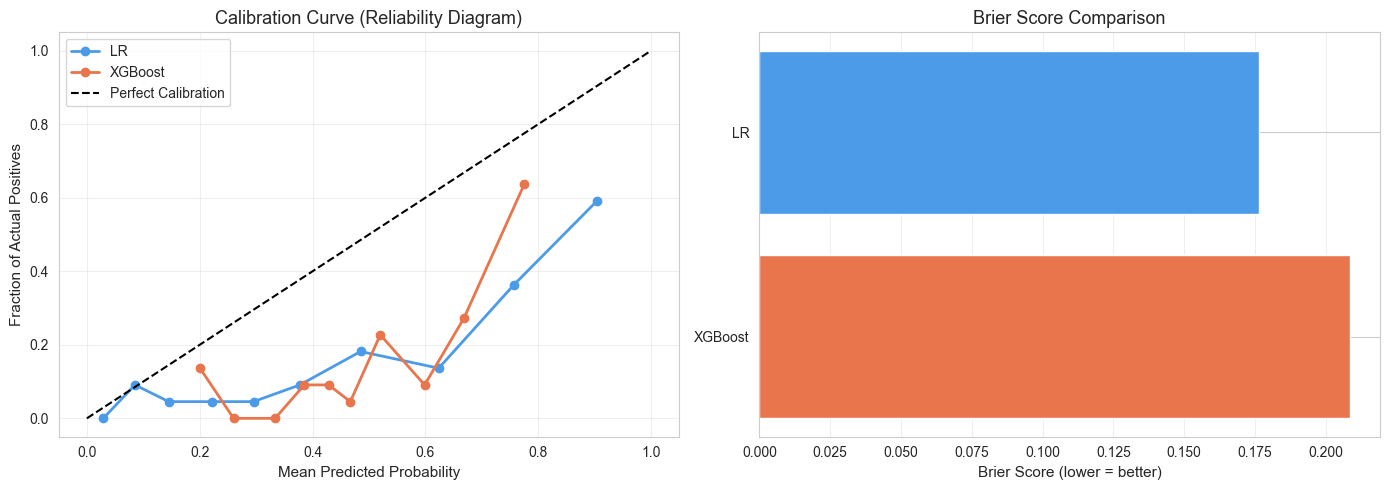

,model,brier_score,log_loss
0,LR,0.1765,0.5279
1,XGBoost,0.2087,0.6042


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, prob, color in [
    ('LR',      lr_val_prob,  '#4C9BE8'),
    ('XGBoost', xgb_val_prob, '#E8754C')
]:
    frac_pos, mean_pred = calibration_curve(y_val, prob, n_bins=10, strategy='quantile')
    axes[0].plot(mean_pred, frac_pos, marker='o', label=name, color=color, lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Actual Positives")
axes[0].set_title("Calibration Curve (Reliability Diagram)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

calibration_metrics = []
for name, prob in [
    ('LR',      lr_val_prob),
    ('XGBoost', xgb_val_prob)
]:
    brier = brier_score_loss(y_val, prob)
    ll    = log_loss(y_val, prob)
    calibration_metrics.append({'model': name, 'brier_score': round(brier, 4),
                                 'log_loss': round(ll, 4)})

calib_df = pd.DataFrame(calibration_metrics).sort_values('brier_score')

axes[1].barh(calib_df['model'], calib_df['brier_score'], color=['#4C9BE8', '#E8754C'])
axes[1].set_xlabel("Brier Score (lower = better)")
axes[1].set_title("Brier Score Comparison")
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig("results/calibration.png", dpi=150, bbox_inches='tight')
plt.show()

calib_df

## 4.18 Cost-Sensitive Learning: Business Cost Matrix

In [95]:
COST_FN = 50000
COST_FP = 200
COST_TP = 1000
COST_TN = 0

def expected_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn * COST_TN + fp * COST_FP + fn * COST_FN + tp * COST_TP

cost_results = []
for t in thresholds:
    preds = (cv_probs >= t).astype(int)
    cm = confusion_matrix(y_train, preds)
    tn, fp, fn, tp = cm.ravel()
    total_cost = tn * COST_TN + fp * COST_FP + fn * COST_FN + tp * COST_TP
    cost_results.append({
        'threshold':         round(t, 2),
        'fn':                int(fn),
        'fp':                int(fp),
        'tp':                int(tp),
        'total_cost_USD':    int(total_cost),
        'cost_per_employee': round(total_cost / len(y_train), 2)
    })

cost_df = pd.DataFrame(cost_results)
cost_df

,threshold,fn,fp,tp,total_cost_USD,cost_per_employee
0,0.10,11,615,155,828000,804.66
1,0.12,16,582,150,1066400,1036.35
2,0.14,16,555,150,1061000,1031.10
3,0.16,18,530,148,1154000,1121.48
4,0.18,18,505,148,1149000,1116.62
5,0.20,19,480,147,1193000,1159.38
6,0.22,20,455,146,1237000,1202.14
7,0.24,23,441,143,1381200,1342.27
8,0.26,25,410,141,1473000,1431.49
9,0.28,27,396,139,1568200,1524.00


In [96]:
threshold_min_cost = cost_df.loc[cost_df['total_cost_USD'].idxmin(), 'threshold']

cost_decision_summary = pd.DataFrame({
    'strategy': ['Min total business cost', 'Max F1', 'Max F2', 'High Recall'],
    'threshold': [threshold_min_cost, threshold_best_f1, threshold_best_f2, threshold_high_recall],
    'total_cost_USD': [
        cost_df.loc[cost_df['threshold']==threshold_min_cost,    'total_cost_USD'].iloc[0],
        cost_df.loc[cost_df['threshold']==threshold_best_f1,     'total_cost_USD'].iloc[0] if (cost_df['threshold']==threshold_best_f1).any() else None,
        cost_df.loc[cost_df['threshold']==threshold_best_f2,     'total_cost_USD'].iloc[0] if (cost_df['threshold']==threshold_best_f2).any() else None,
        cost_df.loc[cost_df['threshold']==threshold_high_recall, 'total_cost_USD'].iloc[0] if (cost_df['threshold']==threshold_high_recall).any() else None
    ]
})
cost_decision_summary

,strategy,threshold,total_cost_USD
0,Min total business cost,0.10,828000
1,Max F1,0.70,3414400
2,Max F2,0.42,2077600
3,High Recall,0.38,1890800


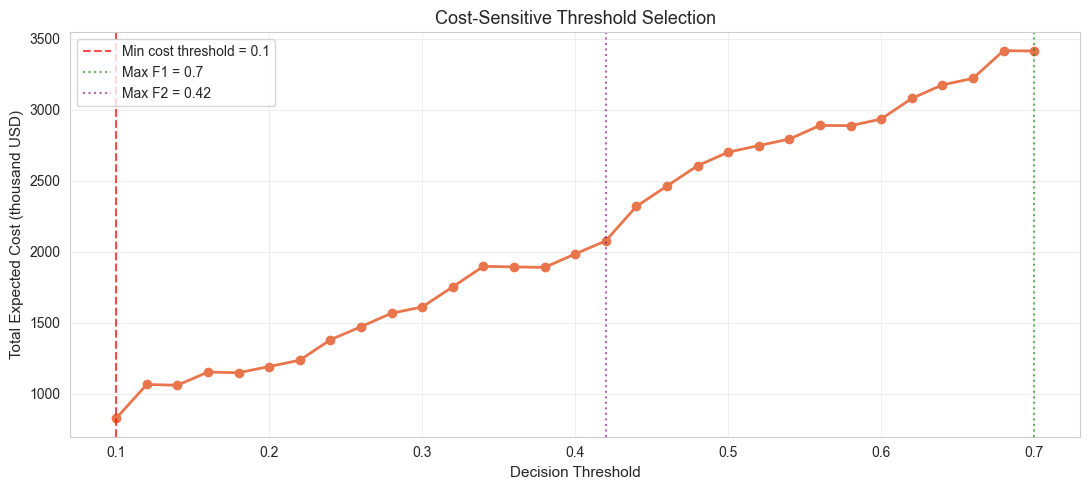

In [97]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cost_df['threshold'], cost_df['total_cost_USD']/1000,
        marker='o', color='#E8754C', lw=2)
ax.axvline(threshold_min_cost, color='red', ls='--', alpha=0.7,
           label=f'Min cost threshold = {threshold_min_cost}')
ax.axvline(threshold_best_f1, color='green',  ls=':', alpha=0.6,
           label=f'Max F1 = {threshold_best_f1}')
ax.axvline(threshold_best_f2, color='purple', ls=':', alpha=0.6,
           label=f'Max F2 = {threshold_best_f2}')
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Total Expected Cost (thousand USD)")
ax.set_title("Cost-Sensitive Threshold Selection")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/cost_sensitive_threshold.png", dpi=150, bbox_inches='tight')
plt.show()

In [98]:
test_pred_min_cost = (best_test_prob >= threshold_min_cost).astype(int)
test_cost_at_optimal = expected_cost(y_test, test_pred_min_cost)
test_cost_at_default = expected_cost(y_test, (best_test_prob >= 0.5).astype(int))
test_cost_at_f1      = expected_cost(y_test, best_test_pred_f1)
test_cost_at_f2      = expected_cost(y_test, best_test_pred_f2)

cost_comparison = pd.DataFrame({
    'strategy':            ['Default (0.5)', 'Max F1', 'Max F2', 'Min Cost'],
    'threshold':           [0.5, threshold_best_f1, threshold_best_f2, threshold_min_cost],
    'test_total_cost_USD': [int(test_cost_at_default), int(test_cost_at_f1),
                            int(test_cost_at_f2), int(test_cost_at_optimal)],
    'savings_vs_default':  [0,
                            int(test_cost_at_default - test_cost_at_f1),
                            int(test_cost_at_default - test_cost_at_f2),
                            int(test_cost_at_default - test_cost_at_optimal)]
})
cost_comparison

,strategy,threshold,test_total_cost_USD,savings_vs_default
0,Default (0.5),0.50,483800,0
1,Max F1,0.70,823000,-339200
2,Max F2,0.42,389400,94400
3,Min Cost,0.10,61800,422000


## 4.19 Model Persistence

In [99]:
joblib.dump(best_model,  "models/best_model.pkl")
joblib.dump(pipeline_lr, "models/lr_baseline.pkl")
joblib.dump(xgb_model,   "models/xgb.pkl")

joblib.dump(final_features, "models/feature_names_lr.pkl")
joblib.dump(xgb_features,   "models/feature_names_xgb.pkl")

preprocessing_params = {
    'income_q25_train':    float(income_q25_train),
    'travel_map':          {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2},
    'gender_map':          {'Male': 0, 'Female': 1},
    'overtime_map':        {'No': 0, 'Yes': 1},
    'nominal_cols':        ['Department', 'EducationField', 'JobRole', 'MaritalStatus'],
    'skewed_features':     ['MonthlyIncome', 'NumCompaniesWorked',
                            'YearsSinceLastPromotion', 'DistanceFromHome', 'YearsAtCompany'],
    'threshold_recommended': float(threshold_best_f2),
    'threshold_min_cost':    float(threshold_min_cost),
    'threshold_max_f1':      float(threshold_best_f1),
    'threshold_max_recall':  float(threshold_high_recall)
}
joblib.dump(preprocessing_params, "models/preprocessing_params.pkl")

metadata = {
    "project":  "IBM Employee Attrition — ERP HR Module",
    "version":  "1.0.0",
    "trained_at": datetime.now().isoformat(),
    "approach": "LR (baseline) vs XGBoost (main model)",
    "best_model": best_model_name,
    "best_model_file": "models/best_model.pkl",
    "preprocessing_file": "models/preprocessing_params.pkl",
    "feature_names_lr_file":  "models/feature_names_lr.pkl",
    "feature_names_xgb_file": "models/feature_names_xgb.pkl",
    "leakage_prevention": [
        "Data split BEFORE feature engineering",
        "Quantile thresholds learned from train only",
        "Scaling inside ImbPipeline for CV integrity",
        "No SMOTE — used class_weight / scale_pos_weight"
    ],
    "dataset": {
        "source":            "WA_Fn-UseC_-HR-Employee-Attrition.csv",
        "n_rows":            int(len(df)),
        "n_features_lr":     len(final_features),
        "n_features_xgb":    len(xgb_features),
        "target":            "Attrition",
        "attrition_rate":    float(df[TARGET_COL].mean()),
        "class_imbalance":   float((y_train == 0).sum() / (y_train == 1).sum())
    },
    "split": {
        "train": int(len(X_train)),
        "val":   int(len(X_val)),
        "test":  int(len(X_test)),
        "random_state": RANDOM_STATE
    },
    "thresholds": {
        "default":    0.50,
        "max_f1":     float(threshold_best_f1),
        "max_f2":     float(threshold_best_f2),
        "max_recall": float(threshold_high_recall),
        "min_cost":   float(threshold_min_cost),
        "recommended": float(threshold_best_f2)
    },
    "business_cost_assumptions": {
        "COST_FN_USD": 50000,
        "COST_FP_USD": 200,
        "COST_TP_USD": 1000,
        "COST_TN_USD": 0,
        "note": "Adjust to company-specific values before production use"
    },
    "test_metrics": {
        "lr_default": {
            "precision": float(precision_score(y_test, (lr_test_prob >= 0.5).astype(int))),
            "recall":    float(recall_score(y_test, (lr_test_prob >= 0.5).astype(int))),
            "f1":        float(f1_score(y_test, (lr_test_prob >= 0.5).astype(int))),
            "roc_auc":   float(roc_auc_score(y_test, lr_test_prob))
        },
        "best_model_max_f2": {
            "precision": float(precision_score(y_test, best_test_pred_f2)),
            "recall":    float(recall_score(y_test, best_test_pred_f2)),
            "f1":        float(f1_score(y_test, best_test_pred_f2)),
            "f2":        float(fbeta_score(y_test, best_test_pred_f2, beta=2)),
            "roc_auc":   float(roc_auc_score(y_test, best_test_prob))
        }
    },
    "bootstrap_ci_95": {
        row['metric']: {
            "estimate": row['estimate'],
            "ci_lower": float(row['95%_CI'].strip('[]').split(', ')[0]),
            "ci_upper": float(row['95%_CI'].strip('[]').split(', ')[1])
        }
        for _, row in bootstrap_df.iterrows()
    } if 'bootstrap_df' in dir() else {},
    "topk_test": {
        f"top_{int(row['k_pct'])}_pct": {
            "k_employees":     int(row['k_employees']),
            "leavers_caught":  int(row['true_leavers_caught']),
            "precision_at_k":  float(row['precision_at_k']),
            "recall_at_k":     float(row['recall_at_k']),
            "lift_at_k":       float(row['lift_at_k'])
        }
        for _, row in test_topk_results.iterrows()
    },
    "web_api": {
        "input_fields": [
            "Age", "Gender", "MaritalStatus", "Education", "EducationField",
            "Department", "JobRole", "JobLevel", "JobInvolvement",
            "BusinessTravel", "OverTime",
            "MonthlyIncome", "StockOptionLevel",
            "EnvironmentSatisfaction", "JobSatisfaction",
            "RelationshipSatisfaction", "WorkLifeBalance",
            "TrainingTimesLastYear",
            "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole",
            "YearsSinceLastPromotion", "YearsWithCurrManager",
            "NumCompaniesWorked", "DistanceFromHome"
        ],
        "output": {
            "attrition_probability": "float [0, 1]",
            "risk_level": "High Risk | Low Risk",
            "threshold_used": "float"
        },
        "derived_features_note": "Backend auto-computes: IsYoung, IsNewHire, HasStockOption, IsLowIncome, OT_LowJobSat, OT_LowEnvSat, OT_LowWLB, ManagerStability, PromotionGap, IncomePerYear, MonthlyIncome_log"
    }
}

with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

pd.DataFrame({
    'file':        ['best_model.pkl', 'lr_baseline.pkl', 'xgb.pkl',
                    'feature_names_lr.pkl', 'feature_names_xgb.pkl',
                    'preprocessing_params.pkl', 'metadata.json'],
    'purpose':     ['Best model for prediction (web API)',
                    'LR baseline model',
                    'XGBoost model',
                    'Feature list for LR (44 features)',
                    'Feature list for XGBoost (41 features)',
                    'Preprocessing thresholds, encodings, threshold values',
                    'All metadata, metrics, web API spec']
})

,file,purpose
0,best_model.pkl,Best model for prediction (web API)
1,lr_baseline.pkl,LR baseline model
2,xgb.pkl,XGBoost model
3,feature_names_lr.pkl,Feature list for LR (44 features)
4,feature_names_xgb.pkl,Feature list for XGBoost (41 features)
5,preprocessing_params.pkl,"Preprocessing thresholds, encodings, threshold..."
6,metadata.json,"All metadata, metrics, web API spec"


In [100]:
def predict_attrition(raw_input: dict, threshold: float = None) -> dict:
    import numpy as np
    import pandas as pd
    import joblib

    model        = joblib.load("models/best_model.pkl")
    params       = joblib.load("models/preprocessing_params.pkl")
    feature_names = joblib.load("models/feature_names_lr.pkl")

    if threshold is None:
        threshold = params['threshold_recommended']

    df_input = pd.DataFrame([raw_input])

    df_input['BusinessTravel'] = df_input['BusinessTravel'].map(params['travel_map'])
    df_input['Gender']         = df_input['Gender'].map(params['gender_map'])
    df_input['OverTime']       = df_input['OverTime'].map(params['overtime_map'])

    df_input = pd.get_dummies(df_input, columns=params['nominal_cols'],
                               drop_first=True, dtype=int)

    income_q25 = params['income_q25_train']
    ot = df_input['OverTime'].values[0]

    df_input['IsYoung']         = (df_input['Age'] < 30).astype(int)
    df_input['IsNewHire']       = (df_input['YearsAtCompany'] < 2).astype(int)
    df_input['HasStockOption']  = (df_input['StockOptionLevel'] > 0).astype(int)
    df_input['IsLowIncome']     = (df_input['MonthlyIncome'] < income_q25).astype(int)
    df_input['IsSingle']        = df_input.get('MaritalStatus_Single', 0)
    df_input['OT_LowJobSat']    = int(ot == 1 and df_input['JobSatisfaction'].values[0] <= 2)
    df_input['OT_LowEnvSat']    = int(ot == 1 and df_input['EnvironmentSatisfaction'].values[0] <= 2)
    df_input['OT_LowWLB']       = int(ot == 1 and df_input['WorkLifeBalance'].values[0] <= 2)
    df_input['ManagerStability']= df_input['YearsWithCurrManager'] / (df_input['YearsAtCompany'] + 1)
    df_input['PromotionGap']    = df_input['YearsSinceLastPromotion'] / (df_input['YearsAtCompany'] + 1)
    df_input['IncomePerYear']   = df_input['MonthlyIncome'] / (df_input['TotalWorkingYears'] + 1)

    for col in params['skewed_features']:
        if col in df_input.columns:
            df_input[f'{col}_log'] = np.log1p(df_input[col])

    df_input = df_input.reindex(columns=feature_names, fill_value=0)

    prob = float(model.predict_proba(df_input)[0][1])

    return {
        "attrition_probability": round(prob, 4),
        "risk_level":            "High Risk" if prob >= threshold else "Low Risk",
        "threshold_used":        threshold,
        "risk_score_pct":        round(prob * 100, 1)
    }

example_employee = {
    "Age": 28, "Gender": "Male", "MaritalStatus": "Single",
    "Education": 3, "EducationField": "Life Sciences",
    "Department": "Sales", "JobRole": "Sales Representative",
    "JobLevel": 1, "JobInvolvement": 2, "BusinessTravel": "Travel_Frequently",
    "OverTime": "Yes", "MonthlyIncome": 2500, "StockOptionLevel": 0,
    "EnvironmentSatisfaction": 2, "JobSatisfaction": 2,
    "RelationshipSatisfaction": 3, "WorkLifeBalance": 2,
    "TrainingTimesLastYear": 2, "TotalWorkingYears": 3,
    "YearsAtCompany": 1, "YearsInCurrentRole": 1,
    "YearsSinceLastPromotion": 0, "YearsWithCurrManager": 1,
    "NumCompaniesWorked": 1, "DistanceFromHome": 15
}

result = predict_attrition(example_employee)
pd.Series(result, name='Prediction').to_frame()

,Prediction
attrition_probability,0.9811
risk_level,High Risk
threshold_used,0.42
risk_score_pct,98.1
